# Análisis del Comportamiento de Aplicaciones bajo Diferentes Escenarios de Despliegue

## Integrantes:
* 2225192 - Luis Alejandro Castellanos Barrera
* 2225226 - Luige Alejandro Velasco Hurtado
* 2225116 - Pedro Julian Tavera Cortez




Curso: Principios y prácticas de Desarrollo de Software Orientado a Objetos

Instructor: Gabriel Rodrigo Pedraza Ferreira

## Introducción
Este proyecto final se centra en el análisis empírico del comportamiento de una aplicación bajo
distintos escenarios de despliegue, utilizando contenedores y las herramientas Docker y
Kubernetes. Los estudiantes desplegarán la aplicación en configuraciones que varían desde un único
servidor hasta clústeres de Kubernetes con diferentes niveles de escalabilidad (número de réplicas
y nodos). El objetivo principal es observar y cuantificar métricas de rendimiento clave, como el
tiempo medio de respuesta y el throughput, bajo diferentes cargas, para luego analizar cómo el
entorno de despliegue impacta en la aplicación y extraer conclusiones sobre su escalabilidad y
eficiencia.


## Objetivo General
Analizar el comportamiento de una aplicación bajo diferentes escenarios de despliegue utilizando
herramientas de contenedores como Docker y de orquestación de contenedores como Kubernetes,
observando métricas de rendimiento y escalabilidad para comprender las implicaciones de cada
configuración, especialmente en lo referente al escalado horizontal.

## Aplicacion
Covagro usa Django REST para la API, React/Vite para el frontend y PostgreSQL como base de datos en los despliegues contenedorizados. Para las pruebas se generan datos con `python manage.py seed_data`, incluyendo usuarios, productos, pedidos y movimientos de inventario.

## Metodologia de carga

El plan JMeter `jmeter/covagro-load-test.jmx` realiza autenticacion JWT y consulta endpoints de productos, pedidos y stock bajo. Cada corrida debe registrar: escenario, nodos, replicas, usuarios concurrentes, promedio de respuesta, throughput, porcentaje de errores y percentil 95.

## Analisis

### 1. Escenario Docker Compose
Archivo: docker-compose.yml

Descripción base del archivo y definición de servicios:

* Servicio PostgreSQL
* Servicio backend Django
* Servicio frontend React/Nginx
* Volumen persistente de PostgreSQL

En este escenario se ejecutan tres servicios en una sola máquina: base de datos PostgreSQL, backend Django REST y frontend servido con Nginx. El backend se expone en el puerto 8000 y el frontend en el puerto 3000.

### 2. Escenario Kubernetes con 1 nodo
Archivo del cluster: kubernetes/kind/one-node.yaml

Descripción configuración completa del cluster de 1 nodo

Este escenario crea un cluster Kind con un solo nodo control-plane. Además, configura el mapeo de puertos para acceder al frontend por 30080 y al backend por 30081.

Archivos de despliegue usados:
* kubernetes/base/backend.yaml
* kubernetes/base/frontend.yaml
* kubernetes/base/postgres.yaml

Réplicas iniciales:
* Backend: replicas: 1, archivo backend.yaml
* Frontend: replicas: 1, archivo frontend.yaml
* PostgreSQL: replicas: 1, archivo postgres.yaml

Variación de réplicas:

* Backend con 1 réplica: kubectl -n covagro scale deployment/backend --replicas=1.
* Backend con 2 réplicas: kubectl -n covagro scale deployment/backend --replicas=2.
* Backend con 3 réplicas: kubectl -n covagro scale deployment/backend --replicas=3.


### 3. Escenario Kubernetes con 2 nodos
Archivo del cluster: kubernetes/kind/two-nodes.yaml

Descripción configuración completa del cluster de 2 nodos

Este escenario usa un nodo control-plane y un nodo worker. Mantiene los mismos servicios Kubernetes del escenario anterior, pero permite distribuir los pods en más de un nodo.

Archivos de despliegue:
* Backend: kubernetes/base/backend.yaml
* Frontend: kubernetes/base/frontend.yaml
* PostgreSQL: kubernetes/base/postgres.yaml

Variación de réplicas:
* Backend con 1 réplica: kubectl -n covagro scale deployment/backend --replicas=1.
* Backend con 2 réplicas: kubectl -n covagro scale deployment/backend --replicas=2.
* Backend con 3 réplicas: kubectl -n covagro scale deployment/backend --replicas=3.

Estos comandos están documentados en kubernetes/README.md

### Metodología utilizada para generar carga con JMeter
La metodología de carga se basa en ejecutar pruebas automáticas con Apache JMeter sobre los distintos escenarios de despliegue: Docker Compose y Kubernetes con variación de nodos y réplicas. El objetivo es comparar el comportamiento de la aplicación Covagro SII midiendo tiempos de respuesta y throughput.

Archivo principal de prueba JMeter

Archivo: jmeter/covagro-load-test.jmx

Rangos importantes:

* Configuración del grupo de usuarios concurrentes
* Número de usuarios concurrentes
* Tiempo de subida o ramp-up
* Activación del planificador de duración
* Duración total de la prueba
* Autenticación JWT mediante POST /api/token/
* Encabezado de autorización Authorization
* Consulta de productos GET /api/productos/
* Consulta de pedidos GET /api/pedidos/?page_size=50
* Consulta de stock bajo GET /api/productos/stock-bajo/

Este plan simula usuarios concurrentes que primero se autentican con JWT y luego realizan operaciones de lectura sobre endpoints representativos de la API: productos, pedidos y stock bajo.

Script de ejecución de prueba de carga con Apache JMeter

Archivo: scripts/run_jmeter.ps1

Descripción:
* Parámetros configurables
* Creación del directorio de resultados
* Ejecución de JMeter en modo no gráfico
* Ubicación final de resultados

El script permite parametrizar:
* HostName: host de la aplicación.
* Port: puerto del backend.
* Users: número de usuarios concurrentes.
* RampUp: tiempo de arranque gradual.
* Duration: duración de la prueba.
* Scenario: nombre del escenario.
* Nodes: número de nodos.
* Replicas: número de réplicas.

La ejecución se hace en modo no gráfico con jmeter -n, usando el archivo covagro-load-test.jmx, generando un archivo .jtl con muestras y un dashboard HTML en la carpeta results.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/My Drive/modelos/resultados/"

In [ ]:

archivos = glob.glob(os.path.join(base_path, "*.txt"))


def parse_filename(filename):
    basename = os.path.basename(filename).replace('.txt', '')

    if basename.startswith('docker_'):
        parts = basename.split('_')
        escenario = 'docker'
        usuarios = int(parts[1].replace('u', ''))
        replica = 0

    elif basename.startswith('1nodo') or basename.startswith('2nodo'):

        match = re.search(r'(\d+)replica$', basename)
        if match:
            replica = int(match.group(1))
        else:
            replica = 0

        escenario = basename[:5]
        usuarios = 25
    else:
        escenario = 'desconocido'
        usuarios = None
        replica = 0

    return escenario, usuarios, replica

In [ ]:
lista_dfs = []
for arch in archivos:
    esc, usr, rep = parse_filename(arch)
    try:

        df = pd.read_csv(arch, on_bad_lines='skip')

        if 'success' in df.columns:
            df['success'] = df['success'].astype(str).str.lower().map({'true': True, 'false': False})
        df['escenario'] = esc
        df['usuarios'] = usr
        df['replica'] = rep
        df['archivo'] = os.path.basename(arch)
        lista_dfs.append(df)
    except Exception as e:
        print(f"Error al leer {arch}: {e}")

In [ ]:

df_total = pd.concat(lista_dfs, ignore_index=True)


df_total['elapsed'] = pd.to_numeric(df_total['elapsed'], errors='coerce')


df_total['elapsed_sec'] = df_total['elapsed'] / 1000.0
df_total['success_ok'] = df_total['success'] == True
df_total['error'] = ~df_total['success_ok']


exitos = df_total[df_total['success_ok']].copy()


metricas = exitos.groupby(['escenario', 'usuarios', 'replica', 'label']).agg(
    peticiones=('elapsed', 'count'),
    media_ms=('elapsed', 'mean'),
    mediana_ms=('elapsed', 'median'),
    p95_ms=('elapsed', lambda x: x.quantile(0.95)),
    p99_ms=('elapsed', lambda x: x.quantile(0.99)),
    max_ms=('elapsed', 'max')
).reset_index()

tasa_error = df_total.groupby(['escenario', 'usuarios', 'replica', 'label'])['error'].mean() * 100
tasa_error = tasa_error.reset_index(name='error_porcentaje')

metricas = metricas.merge(tasa_error, on=['escenario', 'usuarios', 'replica', 'label'])

In [ ]:

for arch in df_total['archivo'].unique():
    subset = df_total[df_total['archivo'] == arch]
    n_rows = len(subset)
    n_success = subset['success_ok'].sum()
    print(f"{arch:30} filas: {n_rows:4}, exitosas: {n_success}")

docker_25u.txt                 filas:   63, exitosas: 63
docker_50u.txt                 filas:   85, exitosas: 85
docker_100u.txt                filas:  160, exitosas: 158
1nodo1replica.txt              filas:   92, exitosas: 52
1nodo2replica.txt              filas:  123, exitosas: 46
1nodo3replica.txt              filas:  133, exitosas: 44
2nodo1replica.txt              filas:  127, exitosas: 60
2nodo2replica.txt              filas:   91, exitosas: 76
2nodo3replica.txt              filas:   76, exitosas: 60


In [ ]:

for arch in archivos:
    esc, usr, rep = parse_filename(arch)
    print(f"{os.path.basename(arch):30} -> escenario: {esc:8}, usuarios: {usr}, réplica: {rep}")

docker_25u.txt                 -> escenario: docker  , usuarios: 25, réplica: 0
docker_50u.txt                 -> escenario: docker  , usuarios: 50, réplica: 0
docker_100u.txt                -> escenario: docker  , usuarios: 100, réplica: 0
1nodo1replica.txt              -> escenario: 1nodo   , usuarios: 25, réplica: 1
1nodo2replica.txt              -> escenario: 1nodo   , usuarios: 25, réplica: 2
1nodo3replica.txt              -> escenario: 1nodo   , usuarios: 25, réplica: 3
2nodo1replica.txt              -> escenario: 2nodo   , usuarios: 25, réplica: 1
2nodo2replica.txt              -> escenario: 2nodo   , usuarios: 25, réplica: 2
2nodo3replica.txt              -> escenario: 2nodo   , usuarios: 25, réplica: 3


In [ ]:

print(metricas.to_string())

   escenario  usuarios  replica           label  peticiones       media_ms  mediana_ms     p95_ms     p99_ms    max_ms  error_porcentaje
0      1nodo        25        1     GET pedidos           3  180604.000000    179833.0  190063.30  190972.66  191200.0         83.333333
1      1nodo        25        1   GET productos          23   67083.478261     50373.0  134498.90  139905.36  141283.0         20.689655
2      1nodo        25        1      POST token          26   27608.461538     15072.5  110298.75  130382.00  130618.0         16.129032
3      1nodo        25        2     GET pedidos           3  233469.000000    243046.0  243127.00  243134.20  243136.0         90.000000
4      1nodo        25        2   GET productos          18   35924.500000      8800.0  137568.70  137771.34  137822.0         47.058824
5      1nodo        25        2      POST token          25   36260.040000     12173.0  145728.20  146798.84  146807.0         39.024390
6      1nodo        25        3     GET p

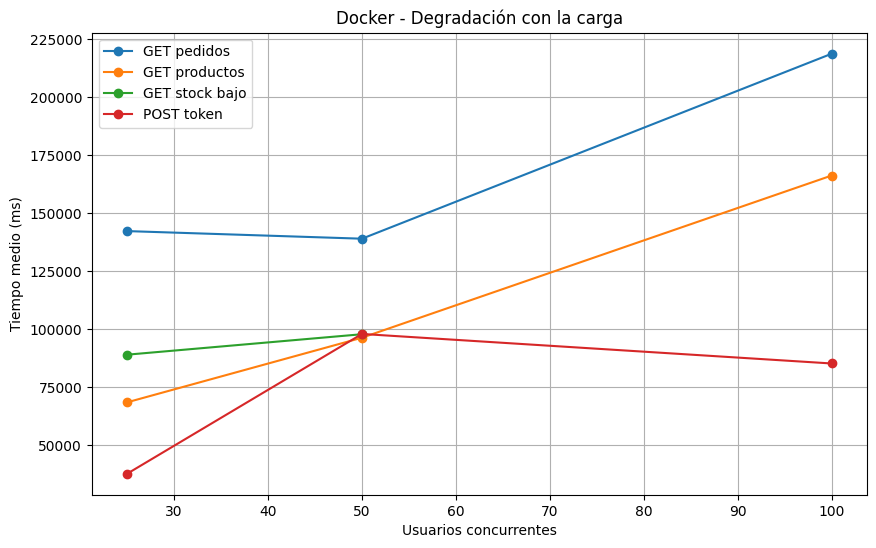

In [ ]:
docker_data = metricas[metricas['escenario'] == 'docker']
plt.figure(figsize=(10,6))
for label in docker_data['label'].unique():
    subset = docker_data[docker_data['label'] == label]
    plt.plot(subset['usuarios'], subset['media_ms'], marker='o', label=label)
plt.xlabel('Usuarios concurrentes')
plt.ylabel('Tiempo medio (ms)')
plt.title('Docker - Degradación con la carga')
plt.legend()
plt.grid(True)
plt.show()


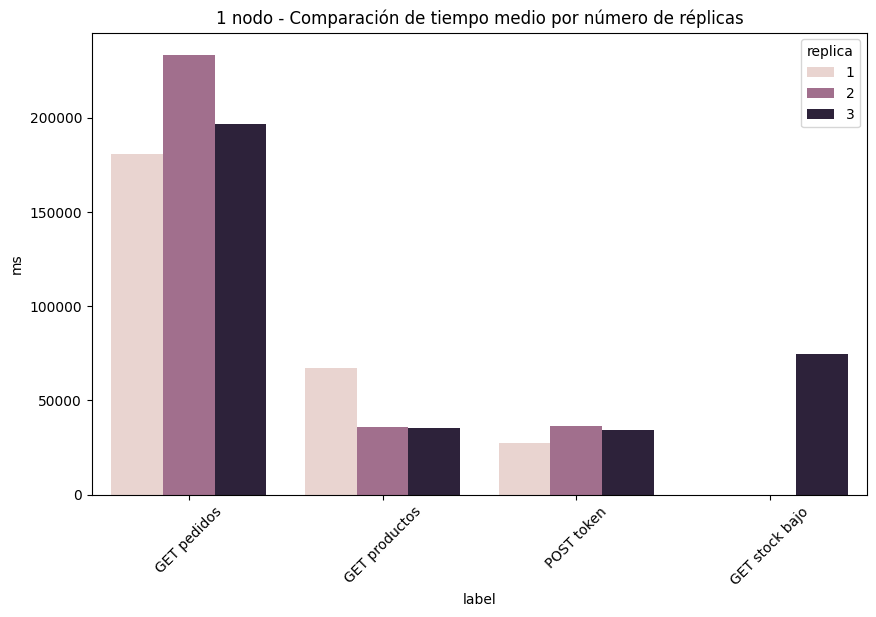

In [ ]:
nodo1_data = metricas[metricas['escenario'] == '1nodo']
plt.figure(figsize=(10,6))
sns.barplot(data=nodo1_data, x='label', y='media_ms', hue='replica')
plt.title('1 nodo - Comparación de tiempo medio por número de réplicas')
plt.xticks(rotation=45)
plt.ylabel('ms')
plt.show()

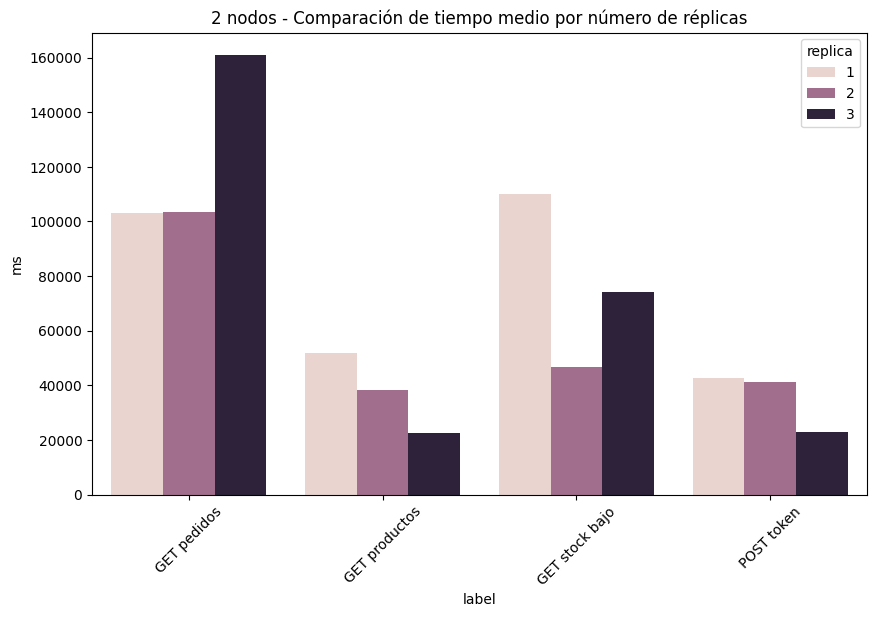

In [ ]:
nodo2_data = metricas[metricas['escenario'] == '2nodo']
plt.figure(figsize=(10,6))
sns.barplot(data=nodo2_data, x='label', y='media_ms', hue='replica')
plt.title('2 nodos - Comparación de tiempo medio por número de réplicas')
plt.xticks(rotation=45)
plt.ylabel('ms')
plt.show()

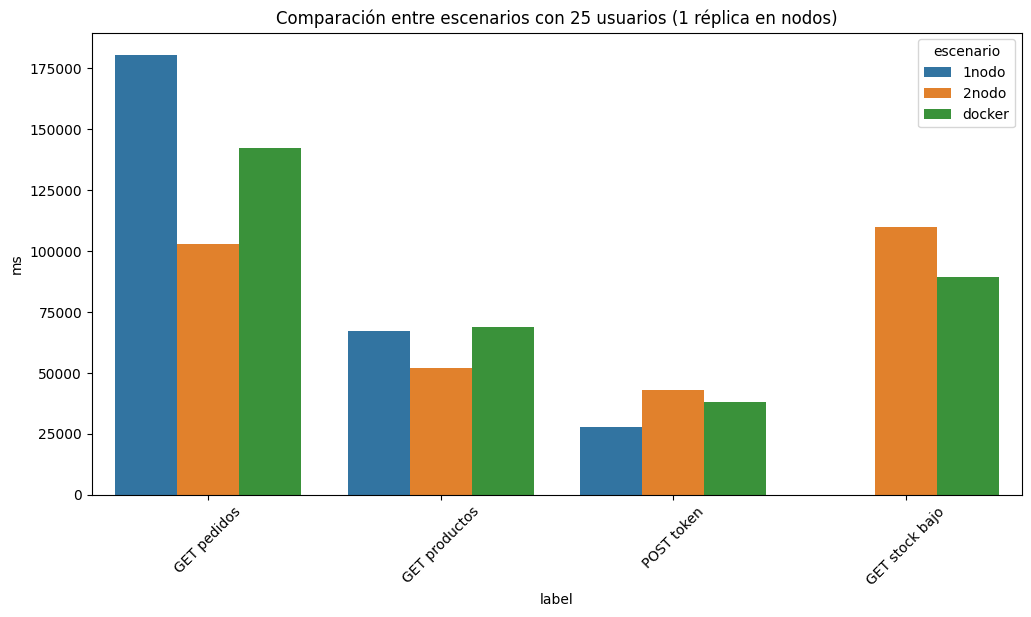

In [ ]:
comparacion_25 = metricas[
    ((metricas['escenario'].isin(['1nodo', '2nodo'])) & (metricas['replica'] == 1)) |
    ((metricas['escenario'] == 'docker') & (metricas['usuarios'] == 25))
]
plt.figure(figsize=(12,6))
sns.barplot(data=comparacion_25, x='label', y='media_ms', hue='escenario')
plt.title('Comparación entre escenarios con 25 usuarios (1 réplica en nodos)')
plt.xticks(rotation=45)
plt.ylabel('ms')
plt.show()


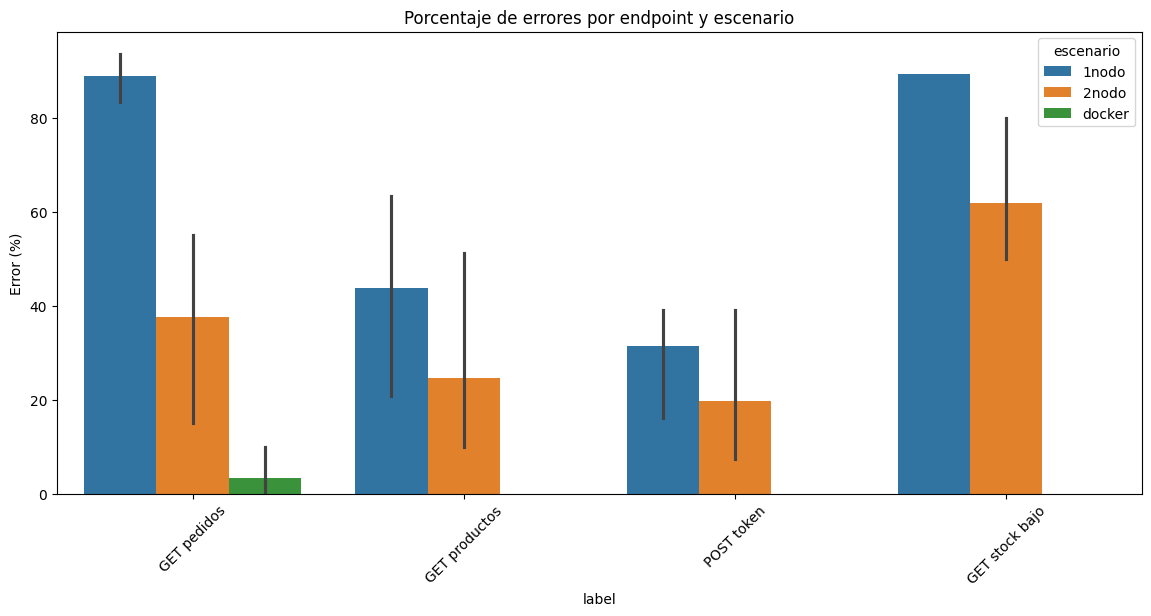

In [ ]:
plt.figure(figsize=(14,6))
sns.barplot(data=metricas, x='label', y='error_porcentaje', hue='escenario')
plt.title('Porcentaje de errores por endpoint y escenario')
plt.xticks(rotation=45)
plt.ylabel('Error (%)')
plt.show()

### Comportamiento general de la aplicación
La aplicación Covagro presenta una degradación de rendimiento a medida que aumenta la carga concurrente, independientemente del escenario de despliegue. Los tiempos de respuesta se disparan (superiores a 100 segundos) y aparecen errores cuando se superan los 25 usuarios concurrentes en cualquier entorno.

### Escenario Docker Compose
Con 25 usuarios, los tiempos medios son moderados. Al aumentar a 50 y 100 usuarios, los tiempos crecen. Docker Compose funciona adecuadamente para cargas bajas (≤25 usuarios), pero no escala bien debido a la arquitectura de un solo nodo y recursos compartidos.

### Escenario Kubernetes con 1 nodo
* 1 réplica: Tiempos muy altos (GET pedidos 180 s) y tasa de error elevada (83 % en pedidos). Indica que el único pod del backend está sobrecargado.
* 2 réplicas: Aumenta ligeramente los tiempos y los errores siguen siendo altos (90 % en pedidos).
* 3 réplicas: Comportamiento similar a 2 réplicas, con errores muy elevados (93 % en pedidos).

Aumentar las réplicas en un solo nodo no mejora significativamente el rendimiento y en algunos casos lo empeora. El cuello de botella no es el número de pods, sino la capacidad del nodo (CPU, memoria)

### Escenario Kubernetes con 2 nodos
* 1 réplica: Tiempos mejores que 1 nodo (GET pedidos 103 s, error 55 %), pero aún altos.
* 2 réplicas: Mejor rendimiento global: GET pedidos 103 s (igual que 1 réplica, pero con menos dispersión), GET productos 38 s, POST token 41 s. La tasa de error baja significativamente (15 % en pedidos, 10 % en productos).
* 3 réplicas: Tiempos ligeramente peores que con 2 réplicas (GET pedidos 161 s), aunque POST token mejora (22 s). Los errores se mantienen moderados (42 % en pedidos).

La distribución de pods entre dos nodos mejora la escalabilidad. La configuración óptima en este escenario es 2 réplicas en 2 nodos

### Comparación entre escenarios (25 usuarios, 1 réplica)

* Docker tiene mejor tiempo en POST token (37 s) y errores nulos, pero peor en GET productos y GET pedidos (68 s y 142 s).
* 1 nodo es el peor escenario: tiempos muy altos y errores masivos.
* 2 nodos ofrece el mejor tiempo en GET pedidos (103 s) y GET productos (51 s), aunque POST token es más lento (42 s) y aún tiene errores (55 %).

Conclusión general: El despliegue en Kubernetes con 2 nodos y 2 réplicas es la mejor opción para aplicaciones con alta demanda de lecturas (productos, pedidos). Sin embargo, la autenticación (POST token) es más rápida en Docker, lo que sugiere que el balanceo de carga entre réplicas añade latencia a las operaciones de escritura/autenticación.